In [1]:
# Example to illustrate how to use cocoa's new feature at commit/89d9300178dd8f645cdc4b1dd3e9e0b55845e760
# Example to illustrate how to use cocoa_lsst_y1's new feature at commit/1e7965bdce7ce568dcc8e6401c81bae201e0ba60
# Commit: "added external_nz_modeling to cosmolike generic interface"

In [2]:
import numpy as np
import cosmolike_lsst_y1_interface as ci
# import euclidemu2
import getdist
import os
import camb
import scipy
import itertools
import iminuit
import functools
import matplotlib.pyplot as plt
import cocoa_photoz as cp

# LSST Y1 redshift distribution. 
To begin, we demostrate the new functionality by passing the LSST Y1 n(z) as an array to the CosmoLike framework. 

In [3]:
def lsst_y1_source_nz():
    path = "../../../external_modules/data/lsst_y1/lsst_y1_source.nz"
    nz_array = np.genfromtxt(path)
    # 1st return: to be used w/ the old feature, 
    # 2nd return: to be used w/ the new feature.
    return path, nz_array

<class 'numpy.ndarray'>


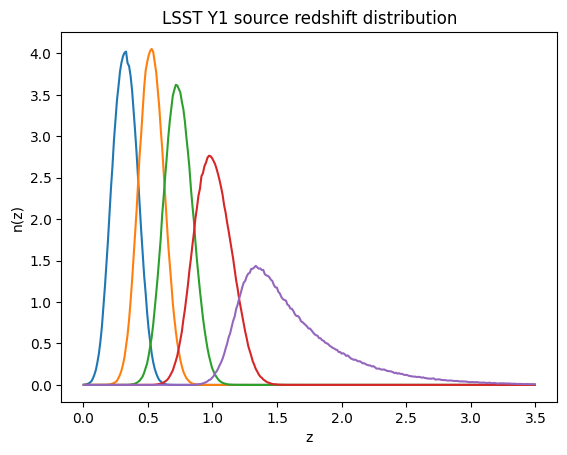

In [4]:
(_ , nz) = lsst_y1_source_nz()
print(type(nz)) # Cosmolike now supports n(z) as a Python array.
for i in range(1,nz.shape[1]):
    plt.plot(nz[:,0],nz[:,i])
plt.xlabel("z")    
plt.ylabel("n(z)")
plt.title("LSST Y1 source redshift distribution");


In [5]:
(theta_of, xip_of, xim_of) = cp.xi(external_nz_modeling=0,mod_nz=lsst_y1_source_nz) # old feature
(theta_nf, xip_nf, xim_nf) = cp.xi(external_nz_modeling=1,mod_nz=lsst_y1_source_nz) # new feature

Old cosmolike feature: nz from file: ../../../external_modules/data/lsst_y1/lsst_y1_source.nz
New cosmolike feature: nz from array: source_nz_local


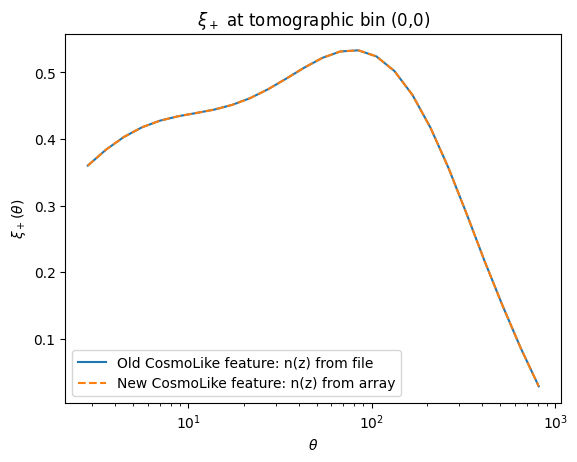

In [6]:
ti, tj = 0, 0 # tomo bin i, tomo bin j
plt.plot(theta_of, theta_of * xip_of[:,ti,tj] * 1e4,ls="-",label="Old CosmoLike feature: n(z) from file")
plt.plot(theta_nf, theta_nf * xip_nf[:,ti,tj] * 1e4,ls="--",label="New CosmoLike feature: n(z) from array")
plt.xscale("log")
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\xi_+(\theta)$")
plt.legend(loc="best")
plt.title(r"$\xi_+$"+f" at tomographic bin ({ti},{tj})");

# Simple modification of the LSST Y1 n(z)
We test a simple modification of the LSST Y1 n(z) by adding uniform random contamination to each nᵢ(zⱼ).

In [7]:
def uniform_random_contamination_nz():
    import random
    random.seed(42)
    path = "../../../external_modules/data/lsst_y1/lsst_y1_source"
    nz_array = np.genfromtxt(path+".nz")
    for i in range(1,nz_array.shape[1]):
        for j in range(nz_array.shape[0]):
            c = random.uniform(0, 0.5)
            nz_array[:,i][j] += c
    np.savetxt(path+"_uniform_random_contamination_nz.nz",nz_array)
    return path+"_uniform_random_contamination_nz.nz",nz_array

<class 'numpy.ndarray'>


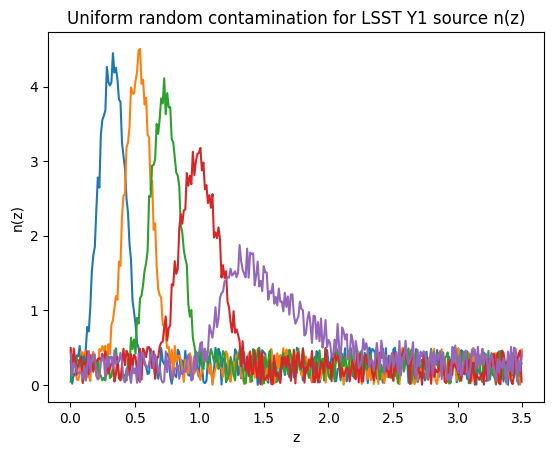

In [8]:
(_ , nz) = uniform_random_contamination_nz()
print(type(nz)) # Cosmolike now supports n(z) as a Python array.
for i in range(1,nz.shape[1]):
    plt.plot(nz[:,0],nz[:,i])
plt.xlabel("z")    
plt.ylabel("n(z)")
plt.title("Uniform random contamination for LSST Y1 source n(z)");


In [9]:
(theta_of, xip_of, xim_of) = \
cp.xi(external_nz_modeling=0,mod_nz=uniform_random_contamination_nz) # old feature
(theta_nf, xip_nf, xim_nf) = \
cp.xi(external_nz_modeling=1,mod_nz=uniform_random_contamination_nz) # new feature

Old cosmolike feature: nz from file: ../../../external_modules/data/lsst_y1/lsst_y1_source_uniform_random_contamination_nz.nz
New cosmolike feature: nz from array: source_nz_local


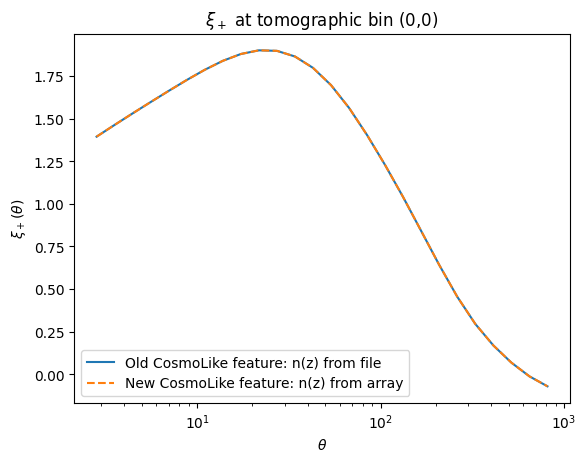

In [10]:
ti, tj = 0, 0 # tomo bin i, tomo bin j
plt.plot(theta_of, theta_of * xip_of[:,ti,tj] * 1e4,ls="-",label="Old CosmoLike feature: n(z) from file")
plt.plot(theta_nf, theta_nf * xip_nf[:,ti,tj] * 1e4,ls="--",label="New CosmoLike feature: n(z) from array")
plt.xscale("log")
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\xi_+(\theta)$")
plt.legend(loc="best")
plt.title(r"$\xi_+$"+f" at tomographic bin ({ti},{tj})");

# LSST SRD redshift distribution
Refs:  
https://github.com/LSSTDESC/CCLX/blob/niko_nz_binning_update/LSST_SRD_Redshift_Distributions_and_Binning.ipynb  
https://arxiv.org/pdf/astro-ph/0506614

In [ ]:
from math import erf, sqrt, exp
"Parameter values from https://github.com/LSSTDESC/CCLX/blob/niko_nz_binning_update/parameters/lsst_desc_parameters.yaml"

n_gal = 18

def n(z):
    alpha, beta, z0 = 0.94, 2, 0.26
    pz = (z/z0)**beta * exp(-(z/z0)**alpha)
    return np.trapz(pz, z)


########################################
########################################
redshift_range = np.asarray(redshift_range)
redshift_distribution = np.asarray(redshift_distribution)

# Calculate the cumulative distribution
cumulative_distribution, total_galaxies = self.compute_cumulative_distribution(redshift_range,
                                                                                redshift_distribution)

# Find the bin edges
bin_edges = []
for i in range(1, n_bins):
    fraction = i / n_bins * total_galaxies
    # Find the redshift value where the cumulative distribution crosses this fraction
    bin_edge = np.interp(fraction, cumulative_distribution, redshift_range)
    bin_edges.append(bin_edge)

return [redshift_range[0]] + bin_edges + [redshift_range[-1]]
sample_dict = {
    "source": self.compute_equal_number_bounds(self.redshift_range,
                                                self.source_sample(),
                                                self.source_params["n_tomo_bins"]),
    "lens": np.arange(self.lens_params["bin_start"],
                      self.lens_params["bin_stop"] + self.lens_params["bin_spacing"],
                      self.lens_params["bin_spacing"])
}

bin_edges = sample_dict[sample_type]
index, (x1, x2) in enumerate(zip(bin_edges[:-1], bin_edges[1:]))
scatter = np.maximum(sigma_z * (1 + self.redshift_range), 1e-10)
upper_limit = (bin_max - self.redshift_range + z_bias) / (np.sqrt(2) * scatter)
lower_limit = (bin_min - self.redshift_range + z_bias) / (np.sqrt(2) * scatter)
########################################
########################################

def x(i,z):
    z_bias, sigma_z = 0, 0.03
    return (zph(i) - z + z_bias) / (sqrt(2) * sigma_z)

def ni(i,z):
    return (1/2) * n(z) * (erf(x(i+1,z)) - erf(x(i,z)))

In [ ]:
z = np.linspace(0,3.5,100)
plt.plot(ni())

# Outliers

# PCA